In [2]:
import pandas as pd 
import numpy as np
import os 
import matplotlib.pyplot as plt 

In [3]:
df = pd.read_csv("ai_chorales.csv")

In [4]:
df.head()

,participant_id,timestamp,age,musical_experience,plays_instrument,sings_in_choir,uses_ai_weekly,confidence_before,confidence_after,difficulty,free_feedback,stimulus,response,correct,correct_response,rt,training
0,e5258291-adb0-4836-96ef-3b394e48b230,2026-05-13T13-35-31-230Z,20,erfahren,ja,nein,ja,unsicher,unsicher,sehr schwer,Ich kenne die Bachchoräle zwar nicht super gut...,data/H/153.5-3.wav,x,m,False,9871,False
1,e5258291-adb0-4836-96ef-3b394e48b230,2026-05-13T13-35-31-230Z,20,erfahren,ja,nein,ja,unsicher,unsicher,sehr schwer,Ich kenne die Bachchoräle zwar nicht super gut...,data/H/256-5.wav,m,m,True,7578,False
2,e5258291-adb0-4836-96ef-3b394e48b230,2026-05-13T13-35-31-230Z,20,erfahren,ja,nein,ja,unsicher,unsicher,sehr schwer,Ich kenne die Bachchoräle zwar nicht super gut...,data/H/227.11-5.wav,m,m,True,9041,False
3,e5258291-adb0-4836-96ef-3b394e48b230,2026-05-13T13-35-31-230Z,20,erfahren,ja,nein,ja,unsicher,unsicher,sehr schwer,Ich kenne die Bachchoräle zwar nicht super gut...,data/H/122.6-4.wav,x,m,False,9712,False
4,e5258291-adb0-4836-96ef-3b394e48b230,2026-05-13T13-35-31-230Z,20,erfahren,ja,nein,ja,unsicher,unsicher,sehr schwer,Ich kenne die Bachchoräle zwar nicht super gut...,data/A/output48-2.wav,x,x,True,8551,False


In [5]:
df["participant_id"].unique()

array(['e5258291-adb0-4836-96ef-3b394e48b230',
       '49e8cb9f-00a0-4469-b2e6-33b7c420825b',
       'fe0f99d8-d9a8-4eed-b1bc-7d638725aa63',
       '697ec336-fe2e-419f-8200-408a6bc1c7b2',
       '94a11270-e293-4b08-acfc-a37f3732dfd6',
       'b59bfe2a-f722-41cb-a61d-64f23e74ac7e',
       '38e4ff2e-76c8-4e46-a668-e695078224d6',
       '5fe84d11-8f05-407d-914e-8c2670675b6a',
       'bd968ff1-edcf-4bd3-930e-4bb8d52f1c65',
       '7cabbdcb-77cd-4936-8bf8-503fe0fa7767',
       '79bd628f-9f0b-49f4-84c4-3b1466aa831f',
       '65a4b228-6ebf-4160-bc06-b1fb17ce87b7',
       '2f215ac8-4ecd-4bc8-b422-babea543b5ed',
       'e2c4c85c-0df4-4edc-8949-17fa86b8f4cd',
       '5460e1ef-2ae5-4096-add9-3ebacc12e7c5',
       'cbeb54ec-0bf0-401f-8ca4-595814a6e497',
       '9537b6d4-9e8d-4330-a559-5c07c2b3b869'], dtype=object)

Mean:  29.41176470588235
Median:  21.0


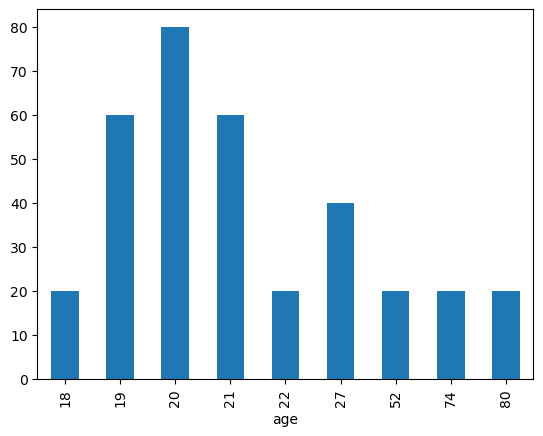

In [7]:
ages = df["age"]

idx = np.arange(0, ages.max())
ages.value_counts().sort_index().plot(kind="bar")
print("Mean: ", ages.mean())
print("Median: ", ages.median())

In [8]:
df.shape

(340, 17)

Experience categories: ['erfahren', 'sehr erfahren', 'sehr unerfahren', 'unerfahren']
                    count       mean  median
musical_experience                          
erfahren                7  10.714286    11.0
sehr erfahren           3  10.000000    11.0
sehr unerfahren         1   8.000000     8.0
unerfahren              6  11.166667    12.0

Pearson correlation (category codes): 0.06922327413251601


/var/folders/jm/_fxyr42d6ndfybfxg6m6d96m0000gn/T/ipykernel_37680/2224394083.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(participant_summary.groupby("musical_experience")["correct_response"].agg(["count", "mean", "median"]))
/var/folders/jm/_fxyr42d6ndfybfxg6m6d96m0000gn/T/ipykernel_37680/2224394083.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  participant_summary.groupby("musical_experience")["correct_response"].mean().plot(


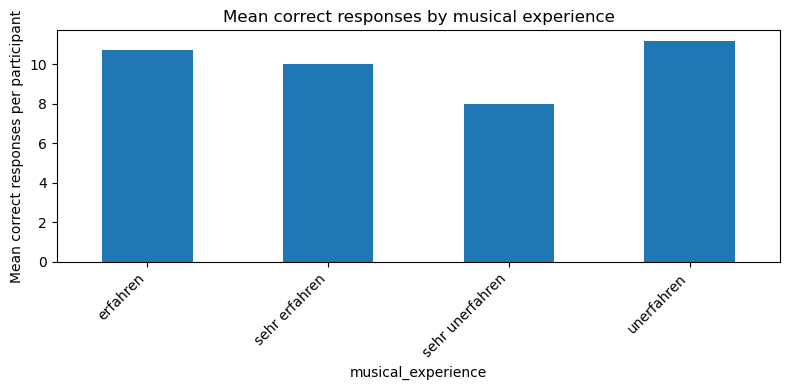

In [ ]:
# vibecoded eval of musical experience impact on experiment performance

participant_summary = (
    df.groupby(["participant_id", "musical_experience"], as_index=False)["correct_response"]
      .sum()
)
participant_summary["musical_experience"] = participant_summary["musical_experience"].astype("category")
participant_summary["experience_code"] = participant_summary["musical_experience"].cat.codes

print("Experience categories:", participant_summary["musical_experience"].cat.categories.tolist())
print(participant_summary.groupby("musical_experience")["correct_response"].agg(["count", "mean", "median"]))

print("\nPearson correlation (category codes):",
      participant_summary["experience_code"].corr(participant_summary["correct_response"]))


_, ax = plt.subplots(figsize=(8, 4))
participant_summary.groupby("musical_experience")["correct_response"].mean().plot(
    kind="bar", ax=ax
)
ax.set_ylabel("Mean correct responses per participant")
ax.set_title("Mean correct responses by musical experience")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

In [11]:
df["timestamp"] = pd.to_datetime(df["timestamp"], format="%Y-%m-%dT%H-%M-%S-%fZ", utc=True)
df.head()

,participant_id,timestamp,age,musical_experience,plays_instrument,sings_in_choir,uses_ai_weekly,confidence_before,confidence_after,difficulty,free_feedback,stimulus,response,correct,correct_response,rt,training
0,e5258291-adb0-4836-96ef-3b394e48b230,2026-05-13 13:35:31.230000+00:00,20,erfahren,ja,nein,ja,unsicher,unsicher,sehr schwer,Ich kenne die Bachchoräle zwar nicht super gut...,data/H/153.5-3.wav,x,m,False,9871,False
1,e5258291-adb0-4836-96ef-3b394e48b230,2026-05-13 13:35:31.230000+00:00,20,erfahren,ja,nein,ja,unsicher,unsicher,sehr schwer,Ich kenne die Bachchoräle zwar nicht super gut...,data/H/256-5.wav,m,m,True,7578,False
2,e5258291-adb0-4836-96ef-3b394e48b230,2026-05-13 13:35:31.230000+00:00,20,erfahren,ja,nein,ja,unsicher,unsicher,sehr schwer,Ich kenne die Bachchoräle zwar nicht super gut...,data/H/227.11-5.wav,m,m,True,9041,False
3,e5258291-adb0-4836-96ef-3b394e48b230,2026-05-13 13:35:31.230000+00:00,20,erfahren,ja,nein,ja,unsicher,unsicher,sehr schwer,Ich kenne die Bachchoräle zwar nicht super gut...,data/H/122.6-4.wav,x,m,False,9712,False
4,e5258291-adb0-4836-96ef-3b394e48b230,2026-05-13 13:35:31.230000+00:00,20,erfahren,ja,nein,ja,unsicher,unsicher,sehr schwer,Ich kenne die Bachchoräle zwar nicht super gut...,data/A/output48-2.wav,x,x,True,8551,False


In [21]:
df.columns

Index(['participant_id', 'timestamp', 'age', 'musical_experience',
       'plays_instrument', 'sings_in_choir', 'uses_ai_weekly',
       'confidence_before', 'confidence_after', 'difficulty', 'free_feedback',
       'stimulus', 'response', 'correct', 'correct_response', 'rt',
       'training'],
      dtype='object')

In [36]:
df = df[[
    'participant_id', 
    'timestamp',
    'age',
    'musical_experience',
    'plays_instrument',
    'sings_in_choir',
    'uses_ai_weekly',
    'confidence_before',
    'confidence_after',
    'difficulty',
    # free_feedback,
    'stimulus',
    'response',  
    'correct',
    'correct_response',
    'rt', 
    # 'training',
        ]]

In [37]:
df.head()

,participant_id,timestamp,age,musical_experience,plays_instrument,sings_in_choir,uses_ai_weekly,confidence_before,confidence_after,difficulty,stimulus,response,correct,correct_response,rt
0,e5258291-adb0-4836-96ef-3b394e48b230,2026-05-13 13:35:31.230000+00:00,20,erfahren,ja,nein,ja,unsicher,unsicher,sehr schwer,data/H/153.5-3.wav,x,m,False,9871
1,e5258291-adb0-4836-96ef-3b394e48b230,2026-05-13 13:35:31.230000+00:00,20,erfahren,ja,nein,ja,unsicher,unsicher,sehr schwer,data/H/256-5.wav,m,m,True,7578
2,e5258291-adb0-4836-96ef-3b394e48b230,2026-05-13 13:35:31.230000+00:00,20,erfahren,ja,nein,ja,unsicher,unsicher,sehr schwer,data/H/227.11-5.wav,m,m,True,9041
3,e5258291-adb0-4836-96ef-3b394e48b230,2026-05-13 13:35:31.230000+00:00,20,erfahren,ja,nein,ja,unsicher,unsicher,sehr schwer,data/H/122.6-4.wav,x,m,False,9712
4,e5258291-adb0-4836-96ef-3b394e48b230,2026-05-13 13:35:31.230000+00:00,20,erfahren,ja,nein,ja,unsicher,unsicher,sehr schwer,data/A/output48-2.wav,x,x,True,8551


In [38]:
df["timestamp"].unique()

<DatetimeArray>
['2026-05-13 13:35:31.230000+00:00', '2026-05-13 13:45:02.945000+00:00',
 '2026-05-13 14:56:55.653000+00:00', '2026-05-13 15:11:24.970000+00:00',
 '2026-05-13 16:25:30.143000+00:00', '2026-05-13 17:18:49.975000+00:00',
 '2026-05-14 08:33:07.650000+00:00', '2026-05-14 09:16:46.252000+00:00',
 '2026-05-14 15:19:46.864000+00:00', '2026-05-16 08:20:03.936000+00:00',
 '2026-05-17 17:23:00.876000+00:00', '2026-05-18 07:38:08.915000+00:00',
 '2026-05-18 13:47:53.446000+00:00', '2026-05-18 14:08:38.727000+00:00',
 '2026-05-19 08:14:12.592000+00:00', '2026-05-19 08:38:32.409000+00:00',
 '2026-05-19 11:38:06.706000+00:00']
Length: 17, dtype: datetime64[ns, UTC]

In [40]:
df = df.sort_values(by=["timestamp", "participant_id"])
df.head()

,participant_id,timestamp,age,musical_experience,plays_instrument,sings_in_choir,uses_ai_weekly,confidence_before,confidence_after,difficulty,stimulus,response,correct,correct_response,rt
0,e5258291-adb0-4836-96ef-3b394e48b230,2026-05-13 13:35:31.230000+00:00,20,erfahren,ja,nein,ja,unsicher,unsicher,sehr schwer,data/H/153.5-3.wav,x,m,False,9871
1,e5258291-adb0-4836-96ef-3b394e48b230,2026-05-13 13:35:31.230000+00:00,20,erfahren,ja,nein,ja,unsicher,unsicher,sehr schwer,data/H/256-5.wav,m,m,True,7578
2,e5258291-adb0-4836-96ef-3b394e48b230,2026-05-13 13:35:31.230000+00:00,20,erfahren,ja,nein,ja,unsicher,unsicher,sehr schwer,data/H/227.11-5.wav,m,m,True,9041
3,e5258291-adb0-4836-96ef-3b394e48b230,2026-05-13 13:35:31.230000+00:00,20,erfahren,ja,nein,ja,unsicher,unsicher,sehr schwer,data/H/122.6-4.wav,x,m,False,9712
4,e5258291-adb0-4836-96ef-3b394e48b230,2026-05-13 13:35:31.230000+00:00,20,erfahren,ja,nein,ja,unsicher,unsicher,sehr schwer,data/A/output48-2.wav,x,x,True,8551


In [41]:
responses_indiv = pd.Series([g["correct_response"].sum() for n, g in df.groupby("timestamp") ])

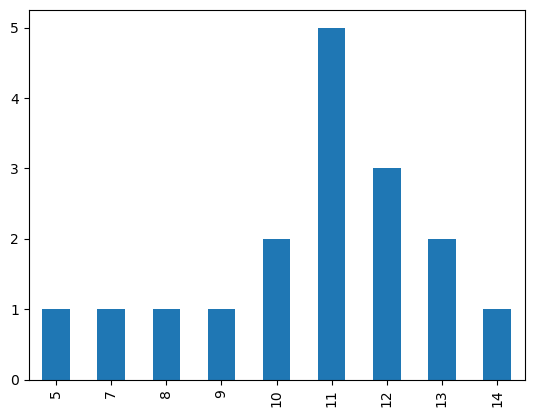

In [42]:
responses_indiv.value_counts().sort_index().plot(kind="bar");

In [12]:
indices, values = zip(*[(n, g["correct_response"].sum()) for n, g in df.groupby("stimulus")])

In [13]:
responses_piece = pd.Series(values, index=indices).sort_index()

Mean: 0.48128342245989303
Median:  0.47058823529411764


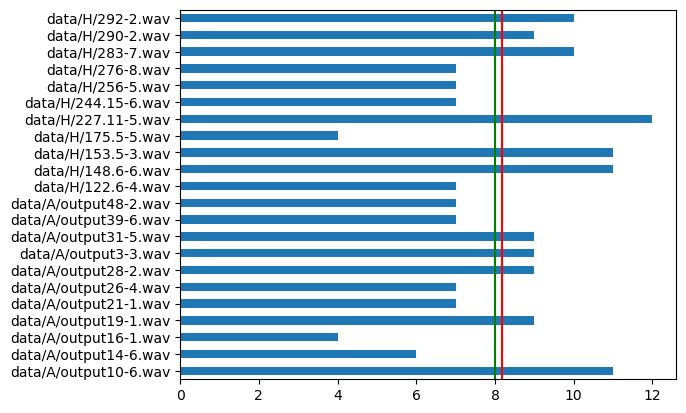

In [20]:
_, ax = plt.subplots()
responses_piece.plot(kind="barh", ax=ax)
avg = responses_piece.mean()
ax.axvline(avg, c="red")
ax.axvline(responses_piece.median(), c="green")
print("Mean:", responses_piece.mean() / 17)
print("Median: ", responses_piece.median() /17);

In [15]:
responses_A, responses_H = responses_piece[:11], responses_piece[11:]

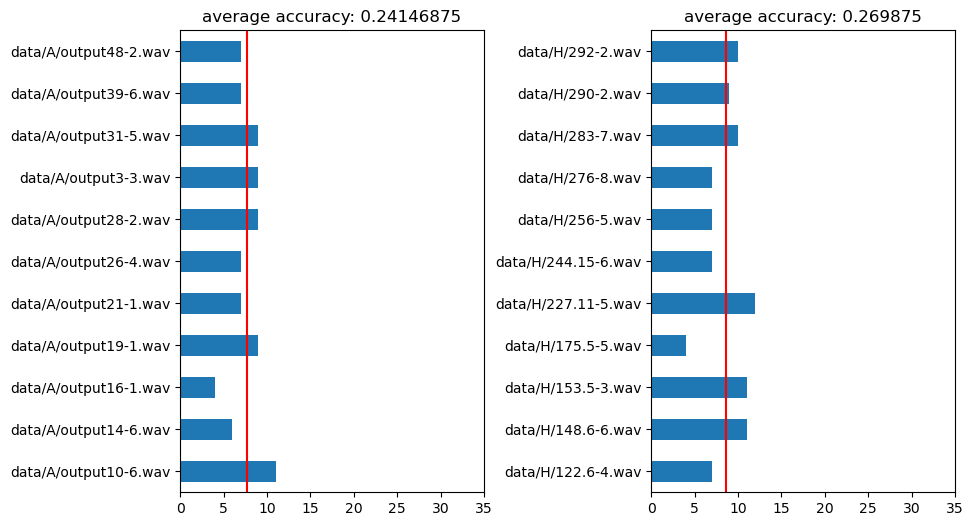

In [16]:
_, axes = plt.subplots(1,2, figsize=(10,6), gridspec_kw={"wspace": .55})
for i, r in enumerate([responses_A, responses_H]):
    r.plot(kind="barh", ax=axes[i])
    avg = round(r.mean(), 3)
    axes[i].axvline(avg, c="red")
    axes[i].set_title(f"average accuracy: {avg/32}")
    axes[i].set_xlim(0,35)
    

**Notizen**

- Alle Beispiele von Menschen einspielen lassen? Oder besser erklären, dass alles maschinell ab gespielt wird.
- Vergleichen: Einspielung vs Synthetisch?
- Bach-Choräle beliebt zum Trainieren, aber wenig Kontakt für Schüler. Wie funktioniert es bei "zugänglicheren" Sachen?
- Frage erweitern: Kann KI-Musik von menschlicher unterscheiden? Ausweitung der Genres etc.
- Notentext einbeziehen? --> Hypothese: Aufgabe wird leichter
- Mit SCB durchführen (oder Choräle spielen lassen)